# 📈 LSTM Forecasting for UK Real Estate Prices

Welcome to this beginner-friendly notebook! 👋

In this notebook, we use **LSTM (Long Short-Term Memory)** – a type of neural network – to forecast **UK real estate prices** based on past trends.

### 🌟 What You’ll Learn:
- How to prepare time series data for forecasting
- How to use LSTM to predict future prices (next 6 months)
- How to visualize and interpret the prediction

We also explain each step in simple terms, so don't worry if you're just starting your Data Science journey!

Let’s forecast the housing market together! 🏡


In [2]:
from google.cloud import storage
import pandas as pd
import os

# Cấu hình
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "gcp-key.json"
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/merged_real_estate_macro.parquet"
local_path = "../data/merged_real_estate_macro.parquet"

# Tải từ GCS nếu chưa có
if not os.path.exists(local_path):
    os.makedirs("../data", exist_ok=True)
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)
    blob.download_to_filename(local_path)
    print(f"✅ Downloaded from GCS → {local_path}")


✅ Downloaded from GCS → ../data/merged_real_estate_macro.parquet


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


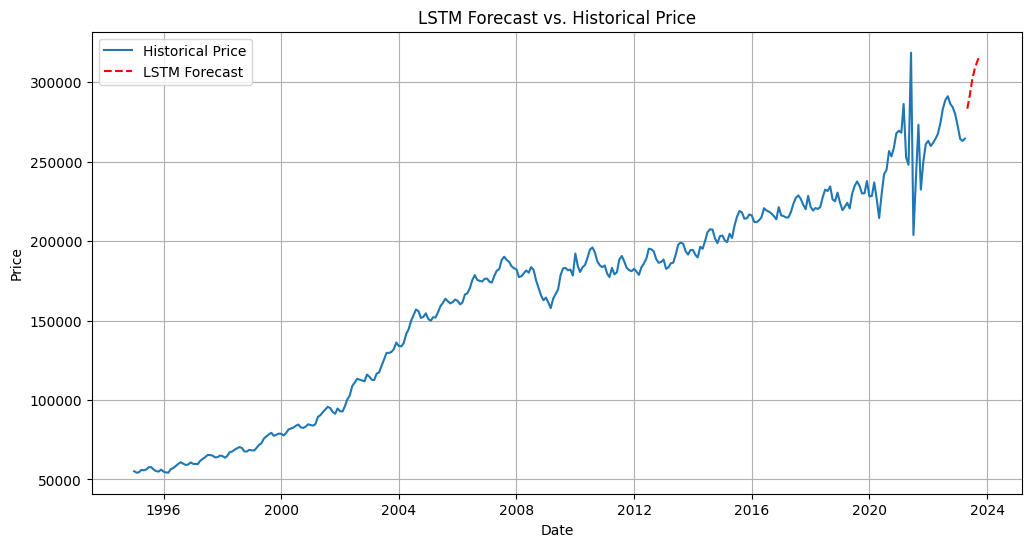

In [3]:
# 📚 Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# 📥 Load dữ liệu từ file parquet (đã lưu local hoặc tải từ GCS trước)
df = pd.read_parquet('../data/merged_real_estate_macro.parquet')
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

# 📊 Tính giá trung bình theo tháng & chuyển log → giá thực
df_monthly = df.groupby('Date')['Log_Price'].mean().reset_index()
df_monthly['Price'] = np.exp(df_monthly['Log_Price'])

# 📏 Scale dữ liệu để LSTM học tốt hơn (0–1)
scaler = MinMaxScaler()
df_monthly['Scaled'] = scaler.fit_transform(df_monthly[['Price']])

# 🔁 Tạo chuỗi thời gian để train LSTM: 12 tháng → 1 tháng
def create_seq(data, steps=12):
    X, y = [], []
    for i in range(len(data)-steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

seq_len = 12
X, y = create_seq(df_monthly['Scaled'].values, seq_len)
X = X.reshape((X.shape[0], X.shape[1], 1))  # reshape đúng input cho LSTM

# 🧠 Xây mô hình LSTM
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100, batch_size=8, verbose=0, callbacks=[EarlyStopping(patience=10)])

# 🔮 Dự báo 6 tháng tiếp theo
last_input = df_monthly['Scaled'].values[-seq_len:]
preds_scaled = []

for _ in range(6):
    pred = model.predict(last_input.reshape(1, seq_len, 1))[0][0]
    preds_scaled.append(pred)
    last_input = np.append(last_input[1:], pred)

# 🧮 Inverse scale → trả về giá thực
pred_prices = scaler.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()
forecast_dates = pd.date_range(df_monthly['Date'].iloc[-1] + pd.DateOffset(months=1), periods=6, freq='MS')

# 📈 Vẽ biểu đồ: LSTM vs Giá thật
plt.figure(figsize=(12,6))
plt.plot(df_monthly['Date'], df_monthly['Price'], label='Historical Price')
plt.plot(forecast_dates, pred_prices, label='LSTM Forecast', color='red', linestyle='--')
plt.title('LSTM Forecast vs. Historical Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
